<a href="https://colab.research.google.com/github/kaushik0212/machine-learning-/blob/main/exp%204%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch    0 | Loss: 0.6934
Epoch  100 | Loss: 0.6721
Epoch  200 | Loss: 0.3492
Epoch  300 | Loss: 0.2942
Epoch  400 | Loss: 0.2858
Epoch  500 | Loss: 0.2843
Epoch  600 | Loss: 0.2839
Epoch  700 | Loss: 0.2836
Epoch  800 | Loss: 0.2833
Epoch  900 | Loss: 0.2831
Epoch 1000 | Loss: 0.2829
Epoch 1100 | Loss: 0.2828
Epoch 1200 | Loss: 0.2826
Epoch 1300 | Loss: 0.2825
Epoch 1400 | Loss: 0.2823

🚀 Final Test Accuracy: 77.50%


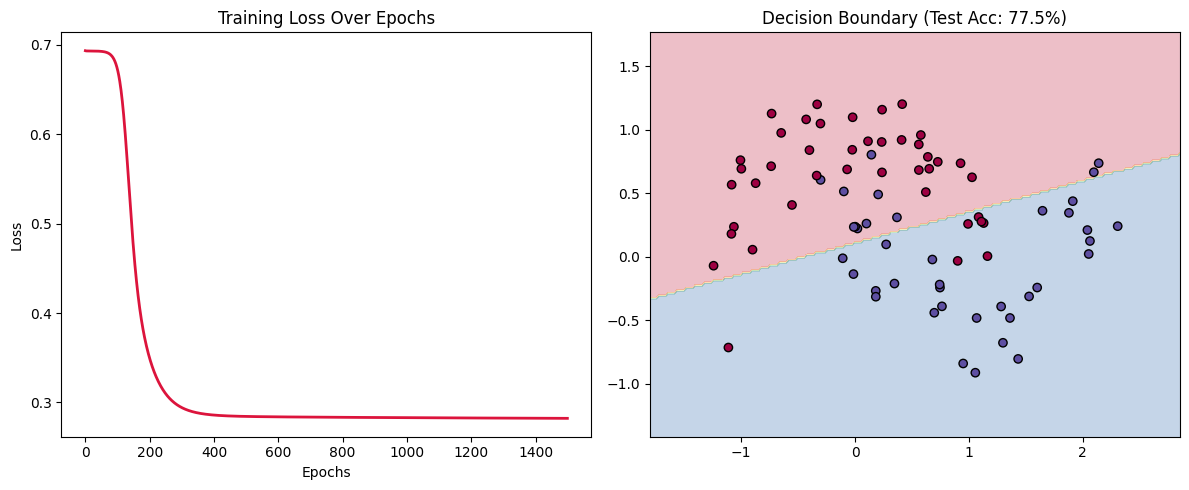

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# --- ACTIVATION FUNCTIONS ---
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# --- NEURAL NETWORK CLASS ---
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate

        # Initialize weights and biases randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        # Input to Hidden Layer
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = sigmoid(self.Z1)

        # Hidden to Output Layer
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y, output):
        m = X.shape[0] # Number of samples

        # Output layer error derivative
        dZ2 = output - y
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer error derivative (Chain rule)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.A1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # Update parameters using Gradient Descent
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        loss_history = []
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            # Binary Cross-Entropy Loss
            loss = -np.mean(y * np.log(output + 1e-15) + (1 - y) * np.log(1 - output + 1e-15))
            loss_history.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")
        return loss_history

    def predict(self, X):
        output = self.forward(X)
        return (output > 0.5).astype(int)

# --- DATASET PREPARATION ---
# Generating non-linearly separable "Moons" dataset
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
y = y.reshape(-1, 1) # Reshape to column vector

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- TRAINING THE MODEL ---
# Network Architecture: 2 inputs -> 5 hidden neurons -> 1 output neuron
nn = NeuralNetwork(input_size=2, hidden_size=5, output_size=1, learning_rate=0.5)
losses = nn.train(X_train, y_train, epochs=1500)

# --- EVALUATION ---
predictions = nn.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f"\n🚀 Final Test Accuracy: {accuracy:.2f}%")

# --- PLOTTING RESULTS ---
plt.figure(figsize=(12, 5))

# Plot 1: Loss over time
plt.subplot(1, 2, 1)
plt.plot(losses, color='crimson', lw=2)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Plot 2: Decision Boundary
plt.subplot(1, 2, 2)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = nn.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
plt.title(f"Decision Boundary (Test Acc: {accuracy:.1f}%)")

plt.tight_layout()
plt.show()